## Hämtar in data och kikar lite 

In [10]:
import os
import pandas as pd

df = pd.read_csv('../data/historical_data.csv')
df = pd.DataFrame(df)

# Skriv ut de första 5 raderna för att dubbelkolla att det ser bra ut
df.head(10)

,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
0,0,8,ad_post,other,urban,android,38.4,2,1,1,594.16,3,91,0,1,0,2.3,0
1,1,4,ad_post,fashion,urban,android,20.0,1,0,1,134.47,2,150,0,0,0,13.6,0
2,2,4,ad_post,other,metro,ios,46.7,3,1,1,198.52,3,72,0,0,0,4.2,0
3,3,3,ad_post,furniture,metro,android,44.3,3,1,2,141.20,3,0,0,0,0,19.8,0
4,4,1,ad_post,electronics,metro,web,211.2,5,0,0,81.39,3,9,0,0,1,23.3,0
5,5,11,message_send,phones,rural,android,31.9,6,0,2,502.33,5,247,0,0,0,26.3,0
6,6,6,message_send,electronics,rural,android,133.9,9,0,0,46.40,2,188,0,0,0,3.2,0
7,7,3,ad_post,other,metro,android,5.8,3,0,0,209.24,4,0,0,0,1,3.5,0
8,8,14,message_send,fashion,urban,web,38.7,4,0,0,41.47,2,135,0,0,1,14.6,0
9,9,1,message_send,other,rural,android,71.1,1,1,1,432.86,6,88,0,0,1,21.8,0


## Undersöker datan


In [11]:


print(df.shape)
print(df.info())
print("\nMissing values per column:\n", df.isna().sum())
print("\nRegion - because we have missing values:\n", df["region"].value_counts(dropna=False))
print("\nTime to first response - because we have missing values:\n", df["time_to_first_response_min"].value_counts(dropna=False))

print("\nTarget distribution\n", df["is_suspicious"].value_counts(normalize=True)) # Hur fördelningen av vår target "suspicious vs non sucpicious" ser ut




(12000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          12000 non-null  int64  
 1   day                         12000 non-null  int64  
 2   event_type                  12000 non-null  object 
 3   category                    12000 non-null  object 
 4   region                      11660 non-null  object 
 5   device                      12000 non-null  object 
 6   account_age_days            12000 non-null  float64
 7   num_prev_listings           12000 non-null  int64  
 8   prev_reports_30d            12000 non-null  int64  
 9   verification_level          12000 non-null  int64  
 10  price                       11182 non-null  float64
 11  num_images                  12000 non-null  int64  
 12  message_length              12000 non-null  int64  
 13  contains_off_platfo

## Checkar numerisk information (medelvärde, minsta, max, varians etc)

In [12]:
df.describe()

target = "is_suspicious"

## Heatmap för de numeriska värdena 

4 variabler har en positiv korrelation med vår target "is_suspicious"

- contains_off_platform
- urgency_words
- payment_attempt
- prev_reports_30d

**Note**: Det som korrelerar negativt med vår target verkar vara account_age_days (desto längre ett konto funnits desto lägre sannolikhet att det utför bedrägrerier)


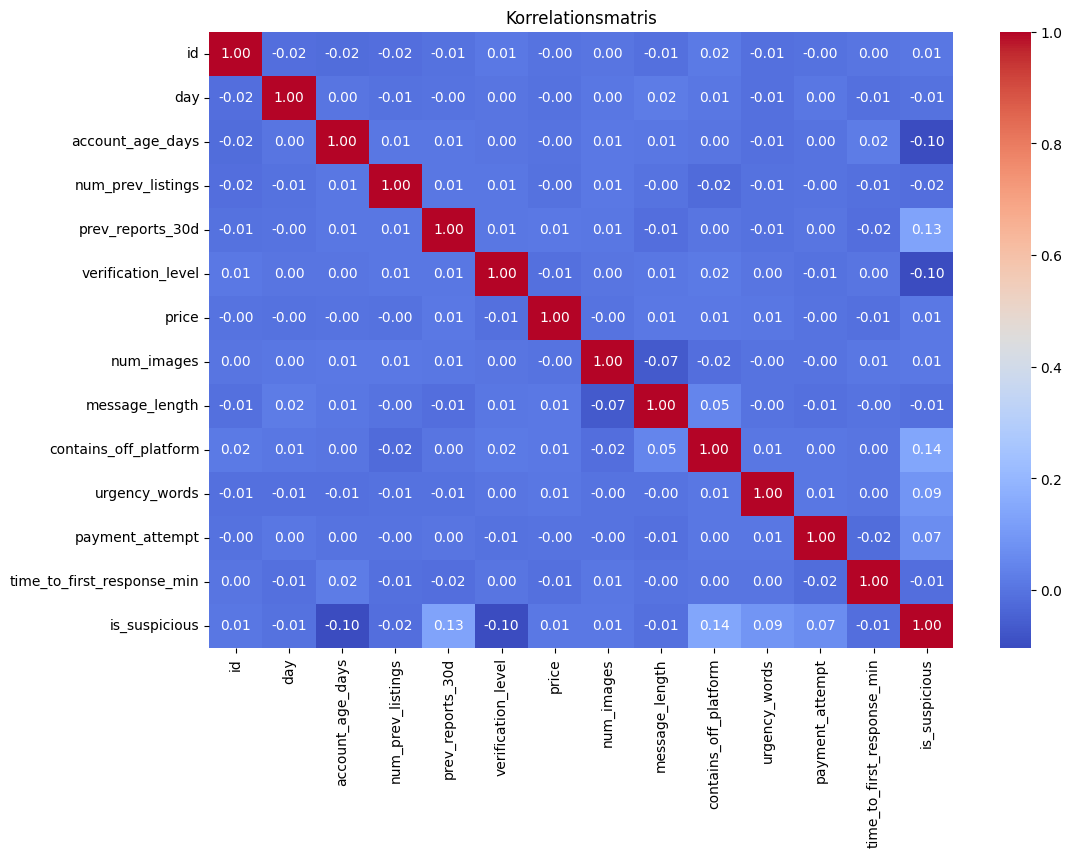

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korrelationsmatris')
plt.show()

### Kikar på hur många unika värden varje string kolumn innehar (hur många kategorier som finns i vardera)

För många unika värden gör string kolumnen svår att bruka, men här har vi mellan 2-6 unika värden vilket är mycket goda nyheter


In [14]:
string_cols = df.select_dtypes(include=['object']).columns

for col in string_cols:
    print(f"{col}: {df[col].nunique()} unika värden")

event_type: 2 unika värden
category: 6 unika värden
region: 3 unika värden
device: 3 unika värden


## Kikar på lite korrelationer med vår target

- Vi inser här att bland "account_age_days" så finns det en hel del outliers (förmodligen inaktiva konton). 
- Skickas en extern länk i kommunikationen mellan köpare/säljare så ökar sannolikheten att det är en bedragare

C:\Users\zanya\AppData\Local\Temp\ipykernel_19384\1250110988.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y='account_age_days', data=df, ax=axes[0], palette='Set2')
C:\Users\zanya\AppData\Local\Temp\ipykernel_19384\1250110988.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='contains_off_platform', y=target, data=df, ax=axes[1], palette='viridis')


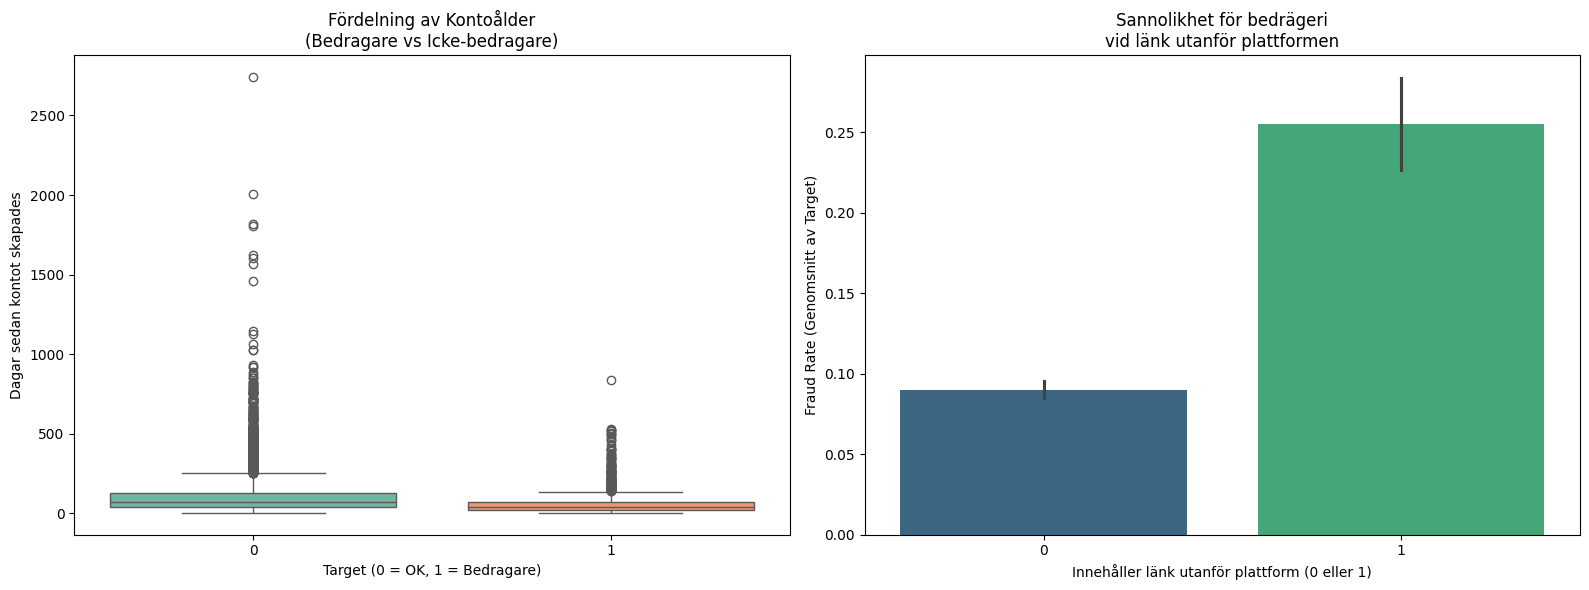

In [15]:
target = "is_suspicious"

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 - Kontots ålder vs potentiellt bedrägeriförsök
sns.boxplot(x=target, y='account_age_days', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Fördelning av Kontoålder\n(Bedragare vs Icke-bedragare)')
axes[0].set_xlabel('Target (0 = OK, 1 = Bedragare)')
axes[0].set_ylabel('Dagar sedan kontot skapades')

# Plot 2 - Sannolikheten för bedrägeri baserat på om de har skickat en länk eller ej
sns.barplot(x='contains_off_platform', y=target, data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Sannolikhet för bedrägeri\nvid länk utanför plattformen')
axes[1].set_xlabel('Innehåller länk utanför plattform (0 eller 1)')
axes[1].set_ylabel('Fraud Rate (Genomsnitt av Target)')

plt.tight_layout()
plt.show()